# Ligand docking workflow — Cefoxitina contra PBP-6 (E. coli)

Pipeline de docking proteína–ligando pequeño con **AutoDock Vina**, complementario al notebook PyMOL.

- **Diana** — PBP-6 de *E. coli* (UniProt P08506, PDB **3IT9** apo). Es una D-Ala-D-Ala carboxipeptidasa de la familia de las PBPs; blanco clásico de β-lactámicos.
- **Ligando** — cefoxitina (PubChem CID **441199**), cefamicina inhibidor covalente de PBPs.
- **Referencia** — **3ITA** (PBP-6 con ampicilina unida covalentemente) para comparar la pose predicha contra el modo de unión experimental.

Cada sección es independiente. Edita el bloque **Setup** y ejecuta en orden.

# Análisis bioquímico — cómo se hace el docking

> Resumen de la metodología y su interpretación bioquímica. Las cifras citadas corresponden a la última ejecución registrada más abajo.

## Sistema biológico

| Rol | Molécula | Identificador | Bioquímica |
|-----|----------|---------------|------------|
| **Diana** | PBP-6 de *E. coli* | UniProt P08506, PDB **3IT9** (apo) | **D-Ala–D-Ala carboxipeptidasa** (penicillin-binding protein). Recorta la D-Ala terminal de los pentapéptidos del peptidoglicano, regulando el entrecruzamiento. Blanco clásico de β-lactámicos. |
| **Ligando** | Cefoxitina | PubChem CID **441199** | **Cefamicina** (cefalosporina 7-α-metoxi). Inhibidor covalente de PBPs: su carbonilo β-lactámico acila la serina catalítica. |
| **Referencia** | PBP-6 + ampicilina | PDB **3ITA** | Complejo *covalente* acil-enzima; sirve de "verdad experimental" para situar un β-lactámico en el bolsillo. |

El sitio activo es un pliegue de **serina transpeptidasa/carboxipeptidasa**, definido por tres motivos conservados (numeración 3IT9):

- **SXXK** → **Ser40** (nucleófilo catalítico) + **Lys43** (base general)
- **SXN** → **Ser106**
- **KTG** → **Lys209**

Estos cuatro residuos (`POCKET_RESIDUES`) anclan toda la caja de docking.

## Método: AutoDock Vina, no covalente y receptor rígido

El flujo es un docking estándar con **AutoDock Vina**. Es clave —y el notebook lo advierte— que **Vina hace docking no covalente y trata el receptor como rígido**. La cefoxitina realmente forma un acil-enzima covalente con Ser40, por lo que la pose predicha se interpreta como un **complejo de Michaelis pre-acilación**, no el estado enlazado real.

**Paso 1 — Preparación del receptor** (`prepare_receptor_pdbqt`, sección 2)
1. Descarga de 3IT9 conservando **solo la cadena A** (el cristal tiene 4 copias A–D; Vina corre sobre una).
2. `clean_structure` elimina aguas (`resn HOH`), iones inorgánicos y confórmeros alternativos (conserva altloc A), que generarían contactos espurios o errores de tipado atómico.
3. PyMOL añade **hidrógenos polares** al polímero (`h_add polymer`), necesarios para la geometría de puentes de H y los tipos atómicos de Vina.
4. meeko escribe el **PDBQT del receptor** (PDB + cargas parciales Q + tipos AutoDock T), con respaldo por CLI `mk_prepare_receptor`.

**Paso 2 — Preparación del ligando** (`load_ligand` + `prepare_ligand_pdbqt`, sección 3)
1. Se descarga la cefoxitina de PubChem como **SDF 3D** (o se embebe desde 2D con RDKit ETKDGv3 + MMFF si no hay registro 3D).
2. RDKit garantiza **hidrógenos explícitos**.
3. meeko asigna **cargas de Gasteiger**, detecta **enlaces rotables** y escribe el PDBQT del ligando — esto es lo que hace el docking *flexible* (se muestrean las torsiones del ligando).
4. Descriptores tipo Lipinski como control: MW 427.46 Da, LogP 0.10, 3 donadores / 9 aceptores de H, 7 enlaces rotables, 28 átomos pesados — coherente con un β-lactámico polar de tamaño fármaco.

**Paso 3 — Caja de búsqueda** (`compute_box`, sección 4)
El centro se fija en el **centroide de los cuatro residuos del bolsillo** y el tamaño se ajusta a su extensión **+ 8 Å de margen** por lado (centro ≈ (7.68, −10.13, −1.03), tamaño ≈ 26 × 25 × 25 Å). Esto enfoca la búsqueda en la hendidura catalítica (**docking dirigido/local**) en lugar de toda la superficie.

**Paso 4 — Docking** (`run_vina`, sección 4)
- Bindings de Python de Vina (respaldo por CLI), función de scoring `vina`.
- `exhaustiveness=16` (mayor que el predeterminado 8 → mejor muestreo del paisaje rugoso), `num_modes=9`, `seed=42` fijo para **reproducibilidad**.
- Salida: hasta 9 poses ordenadas por **energía libre de unión predicha (kcal/mol)** con cotas de RMSD.

## Resultados e interpretación bioquímica

**Afinidades** (sección 4): mejor pose **−7.04 kcal/mol**, con las 8 siguientes agrupadas entre −5.9 y −6.8. El rango estrecho + el bajo RMSD entre las poses 1–3 indican un **modo de unión convergente y consistente** — la búsqueda no dispersa el ligando, vuelve al mismo bolsillo.

**Análisis de contactos** (`ligand_contacts`, sección 5) — residuos a < 4 Å de la mejor pose, la validación bioquímica clave:

| Residuo | Dist. mín. (Å) | Rol |
|---------|----------------|-----|
| **Ser40** | 3.00 | **Nucleófilo catalítico** ✓ |
| **Ser106** | 3.63 | Motivo SXN ✓ |
| Thr210 / Gly211 / Thr212 | 2.3–3.2 | **Hebra KTG** que forma el hueco oxianiónico ✓ |
| Gln105, Arg194 | 2.6–3.3 | Contactos polares del bolsillo |

La cefoxitina dockeada contacta **Ser40, Ser106 y la hebra KTG simultáneamente** — exactamente la maquinaria catalítica que un β-lactámico debe ocupar. Es evidencia fuerte de que la pose es bioquímicamente significativa.

**Distancia catalítica** (sección 5): se mide Ser40 Oγ → carbono electrofílico (C unido a O) más cercano del ligando, seleccionado **por índice de átomo** (el ligando dockeado tiene cadena en blanco y nombres de átomo no únicos, así que una selección por nombre sería ambigua). La distancia resultante es **≈ 3.4 Å**, geometría **pre-acilación plausible**: el carbonilo electrofílico queda a distancia de ataque del nucleófilo Ser40 Oγ, coherente con que la pose no covalente aproxima el complejo de Michaelis previo a la acilación.

**Validación contra el cristal** (sección 6):
- Alineamiento del complejo predicho sobre 3ITA: **RMSD 0.269 Å sobre 2167 átomos** — los esqueletos apo y holo son casi idénticos, así que la suposición de receptor rígido es razonable aquí.
- **Centroide de la cefoxitina dockeada vs. aducto de ampicilina cristalográfico: 2.41 Å.** Que dos β-lactámicos distintos (cefoxitina vs. ampicilina), uno dockeado no covalente y otro unido covalentemente, caigan a ~2.4 Å es **buena concordancia** — confirma que Vina situó el ligando en el farmacóforo real, no en un sitio artefactual.

## Síntesis

El notebook implementa **docking basado en estructura, dirigido, con ligando flexible / receptor rígido** mediante AutoDock Vina, validado de tres formas: (1) ranking de afinidad predicha, (2) huella de contactos contra los residuos catalíticos conocidos y (3) comparación geométrica con un complejo β-lactámico experimental. El encuadre honesto como **aproximación pre-acilación** de una reacción intrínsecamente covalente es bioquímicamente correcto.

**Salvedad principal:** el **mecanismo covalente no se modela** — Vina no forma el enlace Ser40–lactámico; las afinidades son estimaciones no covalentes y no capturan la inhibición irreversible que da potencia a las cefamicinas. La distancia Ser40 Oγ ↔ carbonilo (≈ 3.4 Å) confirma una orientación **competente para la acilación**, pero la reacción en sí queda fuera del alcance de un docking no covalente (requeriría docking covalente o QM/MM).

## 1. Setup

Variables de entrada y directorio de salida. `LIGAND_SOURCE` acepta CID de PubChem, SMILES o path a un `.sdf`/`.mol2`.

> **Aviso.** Vina hace docking flexible no covalente. Cefoxitina forma realmente acil-enzima con Ser40 — la pose predicha se interpreta como aproximación pre-acilación.

> **Numeración.** UniProt P08506 incluye el péptido señal (1-27). El PDB 3IT9 usa numeración propia: la triada catalítica anotada en UniProt como Ser66/Lys69 corresponde a las posiciones **Ser40/Lys43** del PDB (motivo SXXK), con los motivos auxiliares **Ser106-Gly-Asn** (SXN) y **Lys209-Thr-Gly** (KTG). Estos cuatro residuos definen el bolsillo activo en 3IT9.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, display
from pymol import cmd
import pymol_utils as pu
import ligand_utils as lu

RECEPTOR_PDB = "3IT9"
REFERENCE_PDB = "3ITA"
LIGAND_SOURCE = "441199"   # PubChem CID; can also be a SMILES or path
# 3IT9 numbering: SXXK = Ser40-Lys43, SXN at Ser106, KTG at Lys209
POCKET_RESIDUES = [("A", 40), ("A", 43), ("A", 106), ("A", 209)]
RECEPTOR_CHAINS = ["A"]    # 3IT9 has 4 copies (A-D); meeko/Vina runs on one chain
LIGAND_RESN = "UNL"        # residue name meeko/Vina write for the docked ligand
BOX_PADDING = 8.0
EXHAUSTIVENESS = 16
NUM_MODES = 9
FORCE = False              # set True to recompute the (slow) receptor prep + dock
OUT = Path("./out_ligand").resolve()
OUT.mkdir(exist_ok=True)


def build_complex(receptor_pdb, pose_pdb, out_pdb):
    """Concatenate a receptor PDB and a docked-pose PDB into one complex file."""
    rec_lines = [l for l in Path(receptor_pdb).read_text().splitlines() if not l.startswith("END")]
    pose_lines = [l for l in Path(pose_pdb).read_text().splitlines()
                  if l.startswith(("HETATM", "ATOM", "CONECT"))]
    out_pdb = Path(out_pdb)
    out_pdb.write_text("\n".join(rec_lines + pose_lines + ["END", ""]))
    return out_pdb


print("Receptor:", RECEPTOR_PDB, "chains", RECEPTOR_CHAINS)
print("Referencia:", REFERENCE_PDB)
print("Ligando:", LIGAND_SOURCE)
print("Salida:", OUT)

Receptor: 3IT9 chains ['A']
Referencia: 3ITA
Ligando: 441199
Salida: /home/tenshi/molecular-docking-pymol/out_ligand


## 2. Preparar receptor

Descarga, limpia (sin aguas/iones/alt-conformers) y convierte a PDBQT. Renderiza cartoon y superficie con los residuos del bolsillo activo resaltados.

Receptor PDBQT en cache: /home/tenshi/molecular-docking-pymol/out_ligand/receptor_3it9.pdbqt


Receptor limpio:  /home/tenshi/molecular-docking-pymol/out_ligand/receptor_3it9_clean.pdb
Receptor PDBQT:   /home/tenshi/molecular-docking-pymol/out_ligand/receptor_3it9.pdbqt


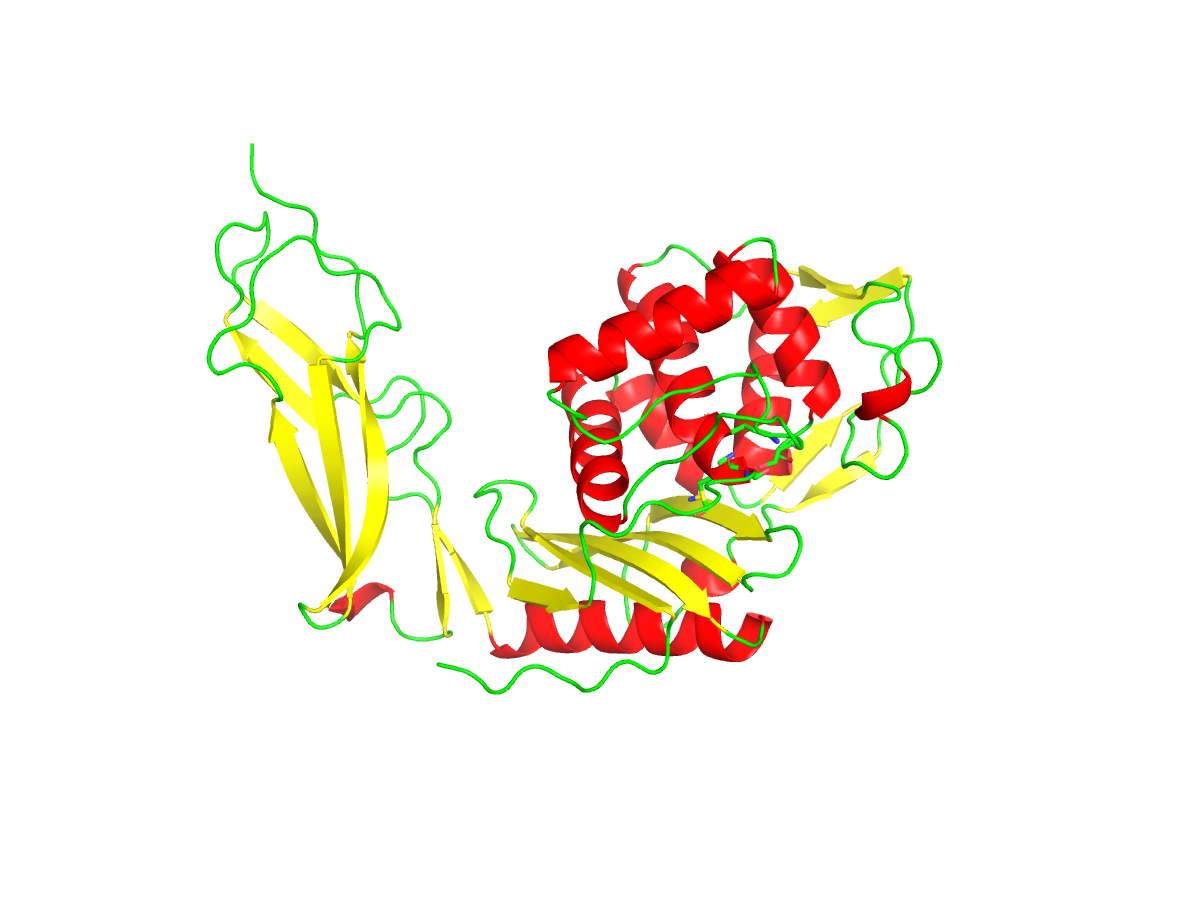

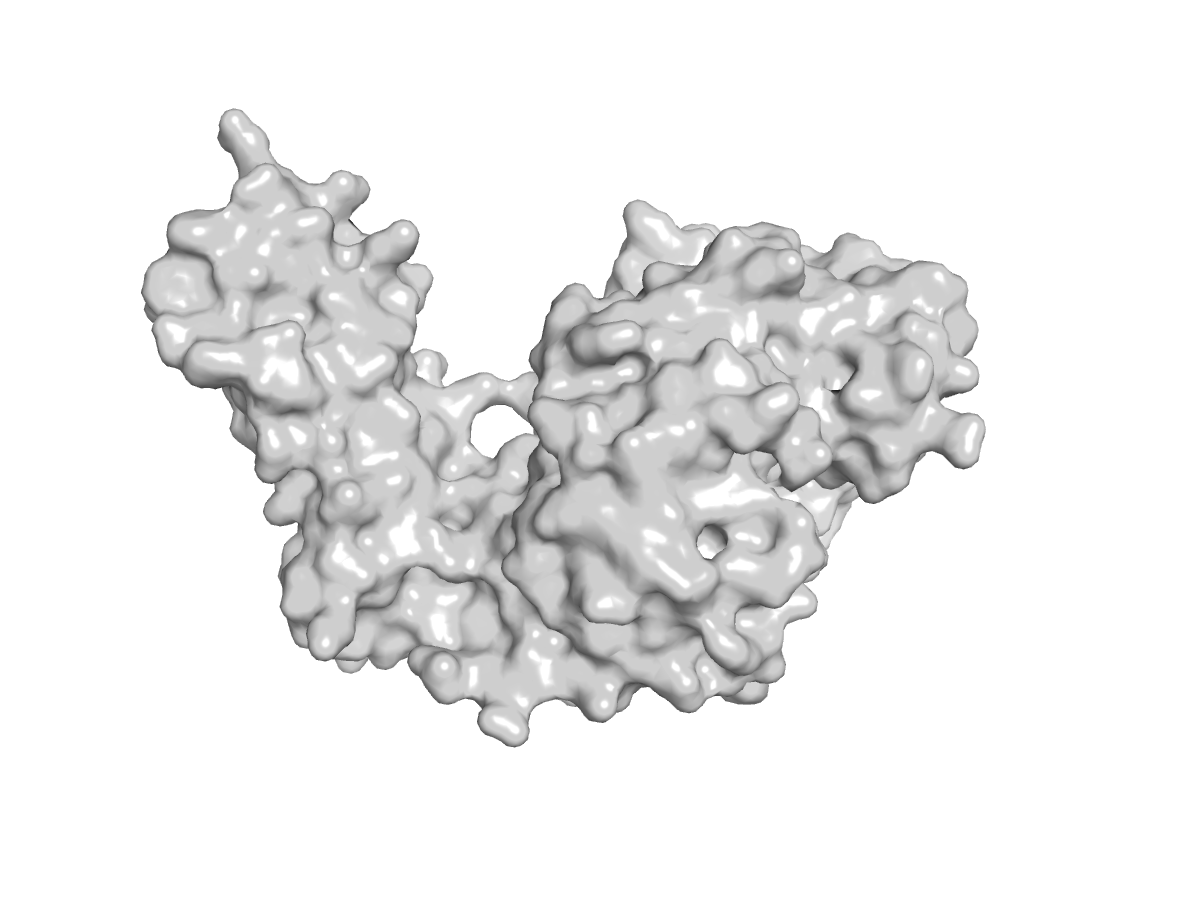

In [2]:
rec_raw = pu.fetch_or_load(RECEPTOR_PDB, OUT)
rec_clean = pu.clean_structure(
    rec_raw,
    OUT / f"receptor_{Path(rec_raw).stem}_clean.pdb",
    keep_chains=RECEPTOR_CHAINS,
)

rec_pdbqt = OUT / f"receptor_{Path(rec_raw).stem}.pdbqt"
if FORCE or not rec_pdbqt.exists():
    rec_pdbqt = lu.prepare_receptor_pdbqt(rec_clean, rec_pdbqt)
else:
    print("Receptor PDBQT en cache:", rec_pdbqt)

# renders are cheap; always regenerate so they track the cleaned structure
rec_cartoon = pu.render_cartoon(
    rec_clean,
    OUT / "receptor_cartoon.png",
    color_by="ss",
    highlight_residues=POCKET_RESIDUES,
)
rec_surface = pu.render_surface(
    rec_clean,
    OUT / "receptor_surface.png",
)

print("Receptor limpio: ", rec_clean)
print("Receptor PDBQT:  ", rec_pdbqt)
for p in (rec_cartoon, rec_surface):
    display(Image(str(p)))

## 3. Preparar ligando

Carga la cefoxitina desde PubChem, asigna hidrógenos y cargas Gasteiger, y guarda el `.pdbqt` para Vina.

In [3]:
lig_mol = lu.load_ligand(LIGAND_SOURCE, OUT)
lig_pdbqt = lu.prepare_ligand_pdbqt(lig_mol, OUT / "ligand.pdbqt")

print("Ligando SDF:   ", lig_mol)
print("Ligando PDBQT: ", lig_pdbqt)

Ligando SDF:    /home/tenshi/molecular-docking-pymol/out_ligand/cid_441199.sdf
Ligando PDBQT:  /home/tenshi/molecular-docking-pymol/out_ligand/ligand.pdbqt


            SMILES: CO[C@@]1(NC(=O)Cc2cccs2)C(=O)N2C(C(=O)O)=C(COC(N)=O)CS[C@@H]21
           MW (Da): 427.46
              LogP: 0.1
     H-bond donors: 3
  H-bond acceptors: 9
   Rotatable bonds: 7
       Heavy atoms: 28


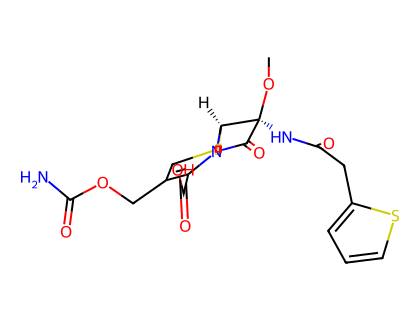

In [4]:
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw

mol = next((m for m in Chem.SDMolSupplier(str(lig_mol), removeHs=False) if m is not None), None)
smiles = Chem.MolToSmiles(Chem.RemoveHs(mol))
metadata = {
    "SMILES": smiles,
    "MW (Da)": round(Descriptors.MolWt(mol), 2),
    "LogP": round(Descriptors.MolLogP(mol), 2),
    "H-bond donors": Descriptors.NumHDonors(mol),
    "H-bond acceptors": Descriptors.NumHAcceptors(mol),
    "Rotatable bonds": AllChem.CalcNumRotatableBonds(mol),
    "Heavy atoms": mol.GetNumHeavyAtoms(),
}
for k, v in metadata.items():
    print(f"{k:>18}: {v}")

display(Draw.MolToImage(Chem.RemoveHs(mol), size=(420, 320)))

## 4. Definir caja y correr Vina

La caja de búsqueda se calcula a partir de los residuos del bolsillo activo en el receptor limpio. Vina explora con `exhaustiveness=EXHAUSTIVENESS` y devuelve hasta `NUM_MODES` poses ordenadas por afinidad.

In [5]:
box = lu.compute_box(rec_clean, POCKET_RESIDUES, padding=BOX_PADDING)
print("Centro (x, y, z): ", tuple(round(v, 2) for v in box["center"]))
print("Tamano (x, y, z): ", tuple(round(v, 2) for v in box["size"]))

docked_pdbqt = OUT / "docked.pdbqt"
affinities_csv = OUT / "affinities.csv"
if not FORCE and docked_pdbqt.exists() and affinities_csv.exists():
    affinities = pd.read_csv(affinities_csv)
    print("Usando dock en cache:", docked_pdbqt)
else:
    affinities = lu.run_vina(
        receptor_pdbqt=rec_pdbqt,
        ligand_pdbqt=lig_pdbqt,
        box=box,
        out_pdbqt=docked_pdbqt,
        exhaustiveness=EXHAUSTIVENESS,
        num_modes=NUM_MODES,
    )
    affinities.to_csv(affinities_csv, index=False)

print("\nAfinidades (kcal/mol):")
affinities

Centro (x, y, z):  (7.68, -10.13, -1.03)
Tamano (x, y, z):  (26.08, 24.71, 24.79)
Usando dock en cache: /home/tenshi/molecular-docking-pymol/out_ligand/docked.pdbqt

Afinidades (kcal/mol):


,mode,affinity,rmsd_lb,rmsd_ub
0,1,-7.038,0.000,0.000
1,2,-6.830,1.473,2.381
2,3,-6.563,1.947,2.559
3,4,-6.511,3.152,5.254
4,5,-6.510,3.286,8.384
5,6,-6.310,2.277,4.043
6,7,-6.222,2.031,2.868
7,8,-6.116,3.535,8.076
8,9,-5.884,2.964,8.489


## 5. Analizar poses

Separa las poses en archivos individuales, construye un complejo receptor + top pose, lista contactos a < 4 Å y mide la distancia Ser40 Oγ ↔ carbonilo del β-lactámico. Renderiza las 3 mejores poses.

In [6]:
poses = lu.split_poses(docked_pdbqt, OUT / "poses")
print(f"Poses extraidas: {len(poses)}")
for i, p in enumerate(poses, 1):
    print(f"  pose {i}: {p}")

# Vina writes PDBQT; convert each pose to PDB (tagged with LIGAND_RESN) so the
# complex-building and analysis cells below can read poses[i].with_suffix(".pdb")
for p in poses:
    cmd.reinitialize()
    cmd.load(str(p), "pose", format="pdbqt")
    cmd.alter("pose", f'resn="{LIGAND_RESN}"')
    cmd.sort()
    cmd.save(str(p.with_suffix(".pdb")), "pose")
    cmd.delete("all")

Poses extraidas: 9
  pose 1: /home/tenshi/molecular-docking-pymol/out_ligand/poses/docked_pose1.pdbqt
  pose 2: /home/tenshi/molecular-docking-pymol/out_ligand/poses/docked_pose2.pdbqt
  pose 3: /home/tenshi/molecular-docking-pymol/out_ligand/poses/docked_pose3.pdbqt
  pose 4: /home/tenshi/molecular-docking-pymol/out_ligand/poses/docked_pose4.pdbqt
  pose 5: /home/tenshi/molecular-docking-pymol/out_ligand/poses/docked_pose5.pdbqt
  pose 6: /home/tenshi/molecular-docking-pymol/out_ligand/poses/docked_pose6.pdbqt
  pose 7: /home/tenshi/molecular-docking-pymol/out_ligand/poses/docked_pose7.pdbqt
  pose 8: /home/tenshi/molecular-docking-pymol/out_ligand/poses/docked_pose8.pdbqt
  pose 9: /home/tenshi/molecular-docking-pymol/out_ligand/poses/docked_pose9.pdbqt


In [7]:
top_pose_pdb = poses[0].with_suffix(".pdb")
complex_pdb = build_complex(rec_clean, top_pose_pdb, OUT / "complex_top.pdb")
print("Complejo top:", complex_pdb)

Complejo top: /home/tenshi/molecular-docking-pymol/out_ligand/complex_top.pdb


In [8]:
contacts = lu.ligand_contacts(complex_pdb, ligand_resn=LIGAND_RESN, cutoff=4.0)
contacts_csv = pu.save_interface_csv(contacts, OUT / "ligand_contacts.csv")
print(f"Contactos receptor-ligando (<4 A): {len(contacts)}")
print(f"CSV: {contacts_csv}")
contacts

Contactos receptor-ligando (<4 A): 13
CSV: /home/tenshi/molecular-docking-pymol/out_ligand/ligand_contacts.csv


,chain,resi,resn,min_dist,n_contacts
0,A,210,THR,2.345,15
1,A,212,THR,2.442,19
2,A,105,GLN,2.625,10
3,A,40,SER,2.996,17
4,A,211,GLY,3.208,11
5,A,104,ILE,3.234,1
6,A,194,ARG,3.263,16
7,A,39,ALA,3.426,3
8,A,149,LEU,3.515,3
9,A,148,GLY,3.529,1


In [9]:
cmd.reinitialize()
cmd.load(str(complex_pdb), "cx")

# Distancia del Oγ catalítico (Ser40, 3IT9) al carbono electrofílico más cercano
# del ligando (C unido a O). Se selecciona por ÍNDICE de átomo: el ligando dockeado
# se escribe con cadena en blanco y nombres no únicos (todos los C se llaman "C"),
# de modo que una selección por nombre es ambigua y cmd.get_distance falla.
ser_og = "/cx//A/SER`40/OG"
ser_distance = None
if cmd.count_atoms(ser_og) == 0:
    print("Aviso: no se encontro Ser40 OG en el receptor; se omite la distancia.")
else:
    carbonyl_idx = []
    cmd.iterate(
        f"resn {LIGAND_RESN} and elem C and bound_to (resn {LIGAND_RESN} and elem O)",
        "carbonyl_idx.append(index)",
        space={"carbonyl_idx": carbonyl_idx},
    )
    if carbonyl_idx:
        distances = []
        for ix in carbonyl_idx:
            try:
                distances.append(cmd.get_distance(ser_og, f"cx and index {ix}"))
            except Exception:
                continue
        if distances:
            ser_distance = min(distances)
            print(f"Carbonos electrofilicos (C-O) en el ligando: {len(carbonyl_idx)}")
            print(f"Distancia Ser40 OG -- carbonilo mas cercano: {ser_distance:.2f} A")
        else:
            print("No se pudo medir distancia Ser40 OG -- carbonilo.")
    else:
        print("No se identifico un carbono carbonilo en el ligando.")
cmd.delete("all")

Carbonos electrofilicos (C-O) en el ligando: 7
Distancia Ser40 OG -- carbonilo mas cercano: 3.38 A


pose 1: /home/tenshi/molecular-docking-pymol/out_ligand/pose_1.png


pose 2: /home/tenshi/molecular-docking-pymol/out_ligand/pose_2.png


pose 3: /home/tenshi/molecular-docking-pymol/out_ligand/pose_3.png


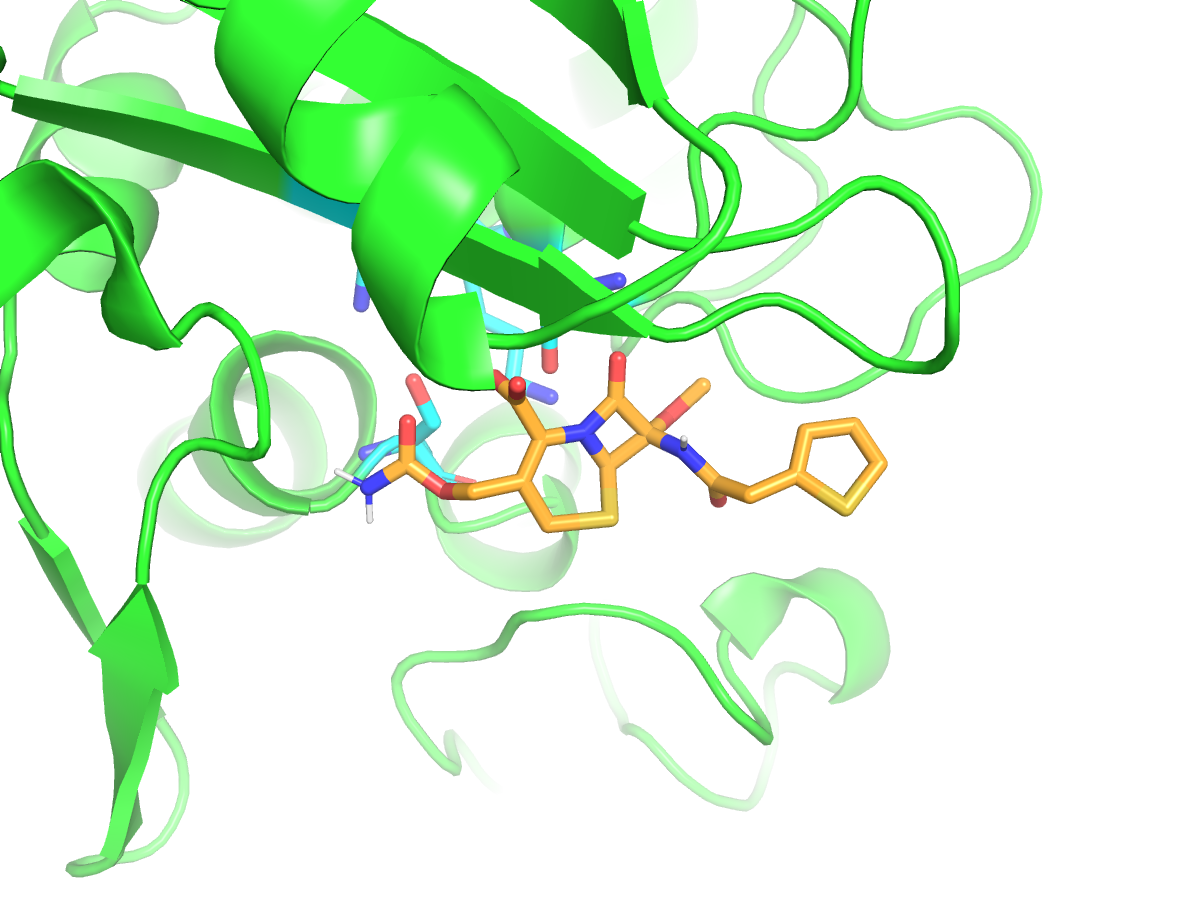

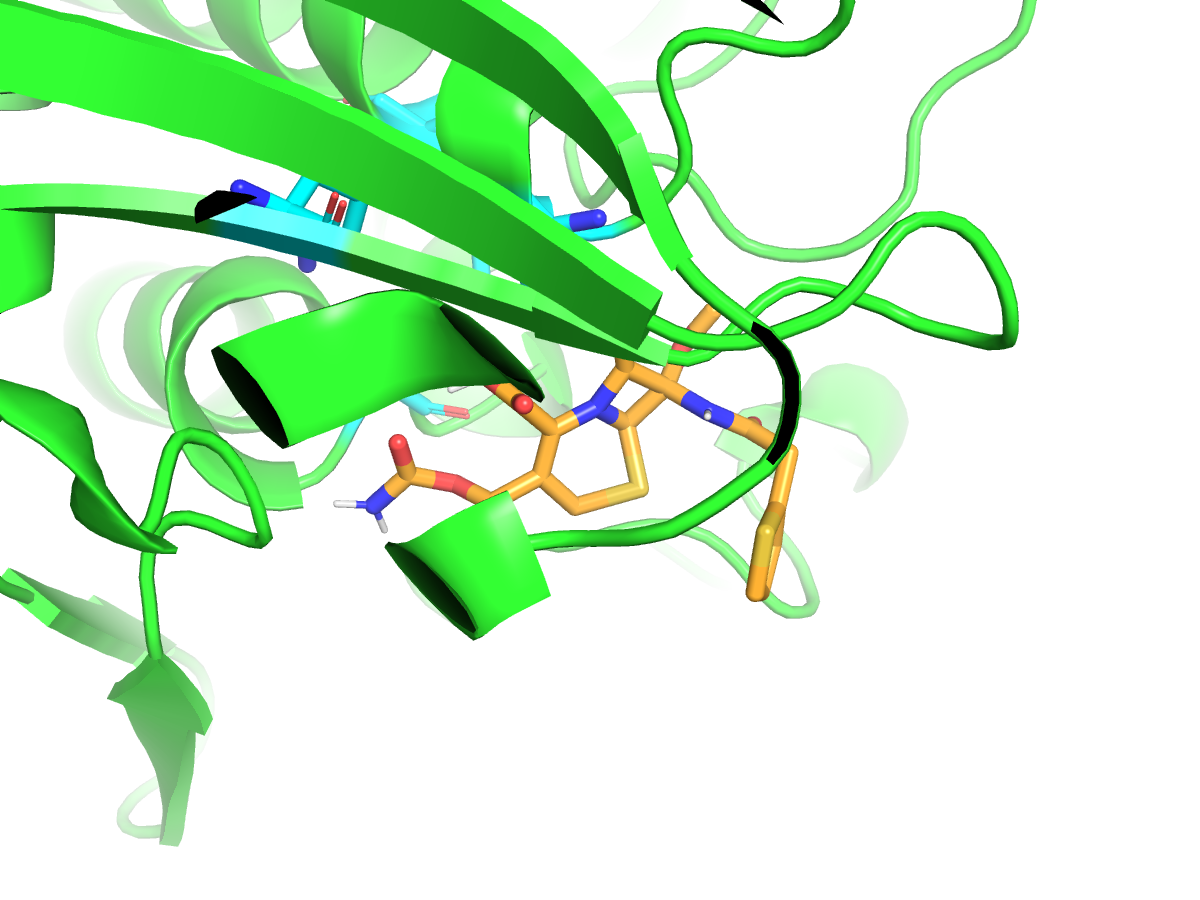

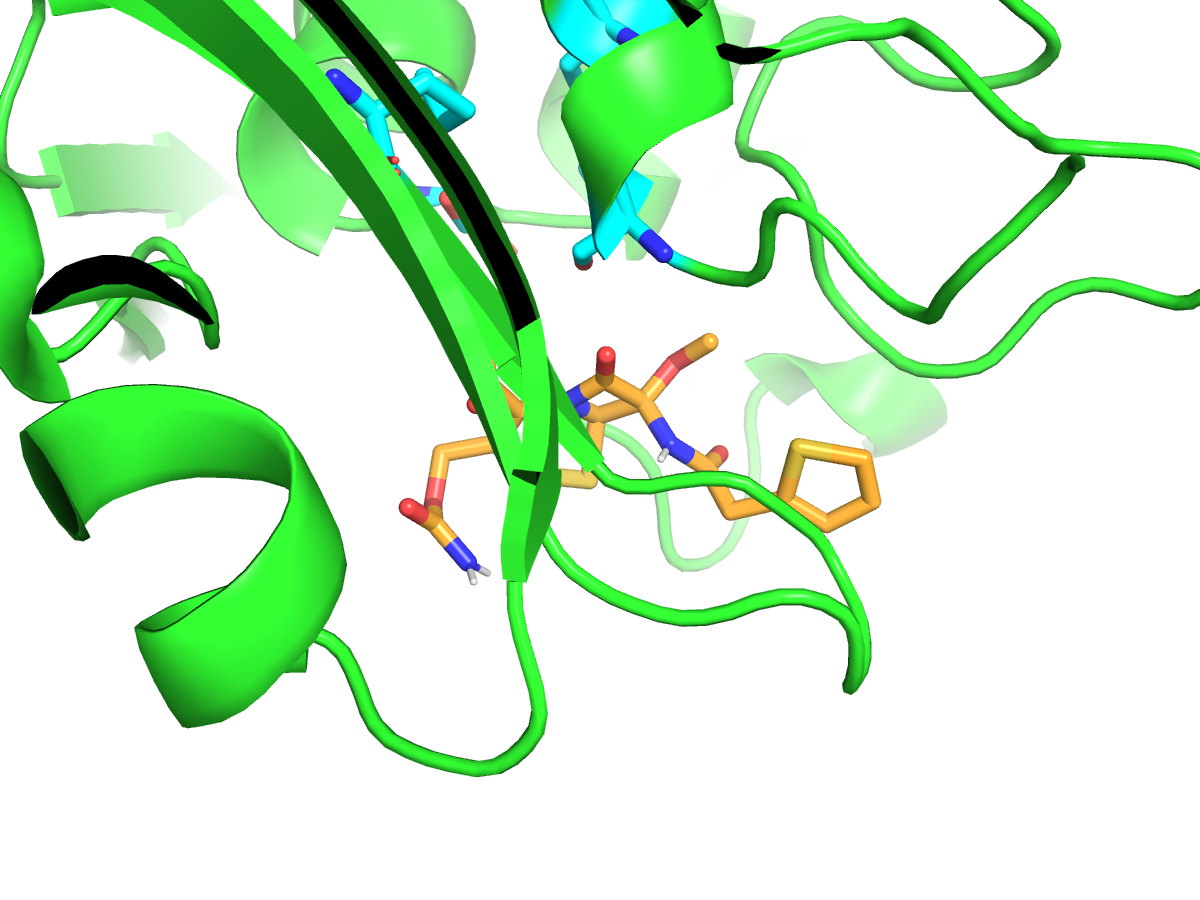

In [10]:
pose_pngs = []
for i, pose in enumerate(poses[:3], 1):
    png = lu.render_pose(
        receptor_pdb=rec_clean,
        pose_pdbqt=pose,
        out_png=OUT / f"pose_{i}.png",
        contact_residues=POCKET_RESIDUES,
    )
    pose_pngs.append(png)
    print(f"pose {i}: {png}")

for p in pose_pngs:
    display(Image(str(p)))

## 6. Comparar contra 3ITA

Alinea el complejo predicho contra 3ITA (PBP-6 + ampicilina) y compara el centroide de la cefoxitina dockeada con el de la ampicilina cristalográfica.

RMSD modelo vs 3ITA: 0.269 A sobre 2167 atomos


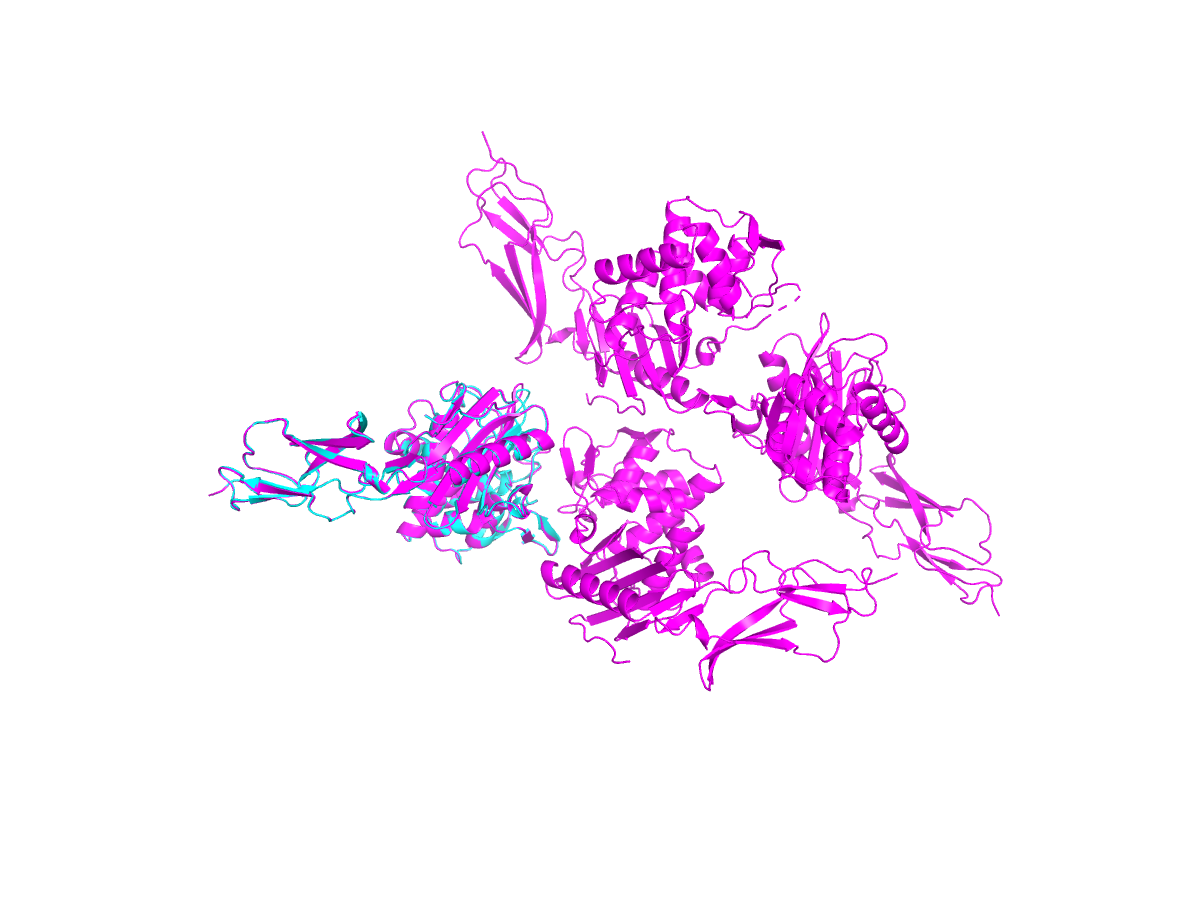

In [11]:
native_raw = pu.fetch_or_load(REFERENCE_PDB, OUT)
native_clean = pu.clean_structure(native_raw, OUT / f"native_{Path(native_raw).stem}_clean.pdb")

align_info = pu.align_to_native(
    complex_pdb,
    native_clean,
    out_png=OUT / "alignment_vs_3ITA.png",
)
print(f"RMSD modelo vs 3ITA: {align_info['rmsd']:.3f} A sobre {align_info['n_atoms']} atomos")
display(Image(str(align_info["png"])))

In [12]:
cmd.reinitialize()
cmd.load(str(complex_pdb), "mdl")   # "model" is a reserved PyMOL keyword
cmd.load(str(native_clean), "native")
cmd.align("mdl", "native")

# 3ITA's covalent acyl-enzyme adduct (ring-opened ampicillin) has HET code AIX.
# Fallback: heteroatoms near the native catalytic Ser40 (the adduct is bonded there).
native_lig_sel = "native and resn AIX"
if cmd.count_atoms(native_lig_sel) == 0:
    native_lig_sel = "(native and hetatm and not polymer) within 6 of (native and resi 40 and name OG)"

docked_coords = cmd.get_coords(f"mdl and resn {LIGAND_RESN}")
native_coords = cmd.get_coords(native_lig_sel)

if docked_coords is None or native_coords is None or len(docked_coords) == 0 or len(native_coords) == 0:
    print("No se pudieron extraer coordenadas de uno de los ligandos.")
    centroid_distance = None
else:
    docked_centroid = docked_coords.mean(axis=0)
    native_centroid = native_coords.mean(axis=0)
    centroid_distance = float(np.linalg.norm(docked_centroid - native_centroid))
    print(f"Centroide cefoxitina dockeada: {docked_centroid.round(2)}")
    print(f"Centroide ampicilina (3ITA):   {native_centroid.round(2)}")
    print(f"Distancia entre centroides:    {centroid_distance:.2f} A")

cmd.delete("all")

Centroide cefoxitina dockeada: [ 11.7  -14.73   3.62]
Centroide ampicilina (3ITA):   [ 12.2  -15.63   5.8 ]
Distancia entre centroides:    2.41 A


## 7. Resumen

Tabla final de las 3 mejores poses y listado de archivos generados.

In [13]:
summary_rows = []
for i in range(min(3, len(poses))):
    pose_complex = build_complex(rec_clean, poses[i].with_suffix(".pdb"), OUT / f"complex_pose{i+1}.pdb")
    contacts_i = lu.ligand_contacts(pose_complex, ligand_resn=LIGAND_RESN, cutoff=4.0)
    row = affinities.iloc[i]
    summary_rows.append({
        "mode": i + 1,
        "affinity_kcal_mol": float(row["affinity"]),
        "rmsd_lb": float(row["rmsd_lb"]),
        "rmsd_ub": float(row["rmsd_ub"]),
        "n_contacts": len(contacts_i),
        "ser40_distance_A": ser_distance if i == 0 else None,
        "centroid_vs_3ITA_A": centroid_distance if i == 0 else None,
    })

summary = pd.DataFrame(summary_rows)
summary_csv = OUT / "summary_top3.csv"
summary.to_csv(summary_csv, index=False)
print("Top 3 poses:")
print(summary.to_string(index=False))
print()

print("Archivos generados:")
for p in sorted(OUT.glob("*")):
    if p.suffix in {".png", ".csv", ".pdb", ".pdbqt", ".sdf", ".log"}:
        print(f"  {p}")

Top 3 poses:
 mode  affinity_kcal_mol  rmsd_lb  rmsd_ub  n_contacts  ser40_distance_A  centroid_vs_3ITA_A
    1             -7.038    0.000    0.000          13          3.377375            2.407184
    2             -6.830    1.473    2.381          14               NaN                 NaN
    3             -6.563    1.947    2.559          13               NaN                 NaN

Archivos generados:


  /home/tenshi/molecular-docking-pymol/out_ligand/3it9.pdb
  /home/tenshi/molecular-docking-pymol/out_ligand/3ita.pdb
  /home/tenshi/molecular-docking-pymol/out_ligand/affinities.csv
  /home/tenshi/molecular-docking-pymol/out_ligand/ala_scan.csv
  /home/tenshi/molecular-docking-pymol/out_ligand/ala_scan.png
  /home/tenshi/molecular-docking-pymol/out_ligand/alignment_vs_3ITA.png
  /home/tenshi/molecular-docking-pymol/out_ligand/cid_441199.sdf
  /home/tenshi/molecular-docking-pymol/out_ligand/complex_pose1.pdb
  /home/tenshi/molecular-docking-pymol/out_ligand/complex_pose2.pdb
  /home/tenshi/molecular-docking-pymol/out_ligand/complex_pose3.pdb
  /home/tenshi/molecular-docking-pymol/out_ligand/complex_top.pdb
  /home/tenshi/molecular-docking-pymol/out_ligand/docked.pdbqt
  /home/tenshi/molecular-docking-pymol/out_ligand/ligand.pdbqt
  /home/tenshi/molecular-docking-pymol/out_ligand/ligand_contacts.csv
  /home/tenshi/molecular-docking-pymol/out_ligand/md_summary.png
  /home/tenshi/molecula

## 8. Scanning de alanina

Scan de alanina computacional sobre los residuos de contacto del bolsillo (sección 5). Cada residuo con cadena lateral se **muta a alanina** (truncando la cadena lateral a Cβ), se **re-prepara el receptor** y se **re-dockea** la cefoxitina en la misma caja, semilla y exhaustiveness reducido (`SCAN_EXHAUSTIVENESS`). Se reporta:

$$\Delta\Delta G = \text{afinidad}_{\text{mut}} - \text{afinidad}_{\text{WT}}$$

- **ΔΔG > 0** → el mutante une *más débilmente* (afinidad menos negativa) ⇒ el residuo es un **hotspot** de unión (umbral ≥ 1 kcal/mol).
- **ΔΔG ≈ 0** → el residuo contribuye poco a la afinidad predicha.
- **ΔΔG < 0** → la mutación *mejora* el score (sitio desfavorable en WT, o reacomodo de la pose).

> **Salvedades.** (1) Es un re-docking: la pose puede reubicarse al perder el residuo, así que ΔΔG mezcla la contribución directa con el reacomodo del ligando. (2) Cadena principal rígida, solo cadena lateral. (3) Scores **no covalentes**, coherentes con el resto del notebook. (4) Se excluyen GLY/ALA/PRO (sin cadena lateral mutable de forma informativa).

In [14]:
# Scanning de alanina: muta cada residuo de contacto (con cadena lateral) a Ala,
# re-prepara el receptor, re-dockea y calcula ddG = afinidad(mut) - afinidad(WT).
SCAN_EXHAUSTIVENESS = 8

# residuos de contacto de la seccion 5, excluyendo GLY/ALA/PRO (sin cadena lateral util)
scan_residues = [
    (r["chain"], int(r["resi"]), r["resn"])
    for _, r in contacts.iterrows()
    if r["resn"] not in {"GLY", "ALA", "PRO"}
]
wt_affinity = float(affinities["affinity"].min())
print(f"WT afinidad (top): {wt_affinity:.3f} kcal/mol")
print("Residuos a escanear:", [f"{rn}{ri}" for _, ri, rn in scan_residues])

ala = lu.alanine_scan(
    rec_clean=rec_clean,
    lig_pdbqt=lig_pdbqt,
    box=box,
    residues=scan_residues,
    out_dir=OUT / "ala_scan",
    wt_affinity=wt_affinity,
    exhaustiveness=SCAN_EXHAUSTIVENESS,
    num_modes=NUM_MODES,
    seed=42,
    force=FORCE,
)
ala_csv = OUT / "ala_scan.csv"
ala.to_csv(ala_csv, index=False)
print(f"\nCSV: {ala_csv}")
ala

WT afinidad (top): -7.038 kcal/mol
Residuos a escanear: ['THR210', 'THR212', 'GLN105', 'SER40', 'ILE104', 'ARG194', 'LEU149', 'SER83', 'SER106']

CSV: /home/tenshi/molecular-docking-pymol/out_ligand/ala_scan.csv


,chain,resi,resn,wt_affinity,mut_affinity,ddG,is_hotspot
0,A,194,ARG,-7.038,-6.582,0.456,False
1,A,149,LEU,-7.038,-6.728,0.310,False
2,A,212,THR,-7.038,-6.733,0.305,False
3,A,40,SER,-7.038,-6.831,0.207,False
4,A,83,SER,-7.038,-6.979,0.059,False
5,A,104,ILE,-7.038,-7.196,-0.158,False
6,A,210,THR,-7.038,-7.216,-0.178,False
7,A,105,GLN,-7.038,-7.234,-0.196,False
8,A,106,SER,-7.038,-7.428,-0.390,False


Figura: /home/tenshi/molecular-docking-pymol/out_ligand/ala_scan.png


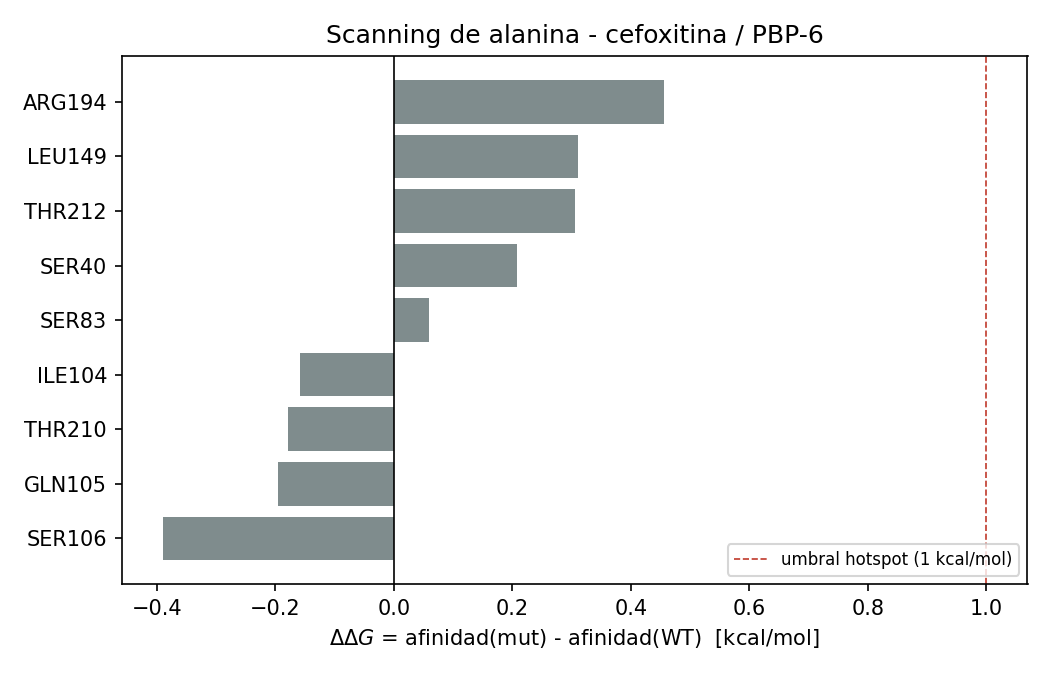

In [15]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

plot_df = ala.dropna(subset=["ddG"]).copy()
plot_df["label"] = plot_df["resn"] + plot_df["resi"].astype(str)
plot_df = plot_df.sort_values("ddG")

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#c0392b" if h else "#7f8c8d" for h in plot_df["is_hotspot"]]
ax.barh(plot_df["label"], plot_df["ddG"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(1.0, color="#c0392b", linestyle="--", linewidth=0.8,
           label="umbral hotspot (1 kcal/mol)")
ax.set_xlabel(r"$\Delta\Delta G$ = afinidad(mut) - afinidad(WT)  [kcal/mol]")
ax.set_title("Scanning de alanina - cefoxitina / PBP-6")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
ala_png = OUT / "ala_scan.png"
fig.savefig(ala_png, dpi=150)
plt.close(fig)
print(f"Figura: {ala_png}")
display(Image(str(ala_png)))

### Resultado del scanning de alanina

WT (referencia) = **−7.038 kcal/mol**. Resultado de re-dockear la cefoxitina contra cada mutante a Ala (exhaustiveness 8, semilla 42):

| Residuo | ΔΔG (kcal/mol) | Lectura |
|---------|----------------|---------|
| **Arg194** | **+0.46** | El más desestabilizante; cadena lateral cargada (+) que coordina los grupos polares/carboxilato de la cefoxitina. |
| Leu149 | +0.31 | Empaquetamiento hidrofóbico de la pared del bolsillo. |
| Thr212 | +0.31 | Hebra KTG, hueco oxianiónico. |
| Ser40 | +0.21 | Nucleófilo catalítico — contribución **subestimada** (ver abajo). |
| Ser83 | +0.06 | Marginal. |
| Ile104 | −0.16 | Quitar la cadena lateral *mejora* el score → reacomodo de la pose. |
| Thr210 | −0.18 | idem. |
| Gln105 | −0.20 | idem. |
| Ser106 | −0.39 | El re-docking gana espacio al vaciar el motivo SXN. |

**Interpretación.** El perfil es **plano: ningún residuo supera el umbral de hotspot (ΔΔG ≥ 1 kcal/mol)**. Esto es coherente y esperable para esta diana/ligando:

1. **La cefoxitina es muy polar y multivalente** (3 donadores / 9 aceptores de H, carboxilato): al eliminar una sola cadena lateral, el ligando recupera casi toda la energía de unión reorganizando sus numerosos contactos alternativos.
2. **Es un re-docking, no un re-scoring de pose fija.** Los ΔΔG **negativos** (Ser106, Gln105, Thr210, Ile104) no son ganancia real de afinidad: al vaciar una cadena lateral voluminosa o polar se abre el bolsillo y la pose re-dockeada encaja algo mejor — el artefacto clásico del scan de alanina por re-docking.
3. **Ser40 sale artificialmente bajo (+0.21).** Vina puntúa de forma **no covalente**; la importancia real de la Ser40 catalítica reside en el enlace acil-enzima covalente, que Vina no modela. Por eso el scan **subestima** justo al residuo bioquímicamente decisivo — una limitación a tener presente al leer estos números.

**Conclusión:** la afinidad predicha de la cefoxitina al bolsillo de PBP-6 está **distribuida sobre toda la maquinaria del sitio activo** (Arg194 polar, pared hidrofóbica Leu149, hebra KTG, Ser40/Ser106), sin depender de un único residuo. El ranking sí es bioquímicamente plausible —Arg194 y la hebra KTG arriba— pero la magnitud absoluta de los ΔΔG está acotada por el carácter no covalente del método.

## 9. Dinámica molecular (MD)

MD del **receptor apo** (PBP-6, cadena A) con **OpenMM**: campo de fuerzas **Amber ff14SB** + **solvente implícito OBC2 (GBSA)**, integrador Langevin (300 K, paso 2 fs, enlaces a H restringidos), acelerado en **GPU (OpenCL)**. Pipeline: minimización → equilibración (`MD_EQUIL_PS`) → producción **2 ns** (`MD_PROD_PS`). Se derivan las métricas pedidas: **RMSD** (backbone vs. frame inicial), **RMSF** (Cα por residuo), **Rg** (radio de giro) y la **energética** (energía potencial y temperatura).

> **Alcance y salvedades.**
> - **Es una MD apo (sin ligando).** La cefoxitina **no se parametriza** porque `openff-toolkit` está retirado de PyPI y AmberTools no es instalable por pip en esta máquina; sin campo de fuerzas del ligando no se puede simular el complejo. La MD informa de la **estabilidad y flexibilidad del sitio activo** del receptor, no de la dinámica del ligando unido.
> - **Solvente implícito** (no aguas explícitas): más rápido y suficiente para RMSD/RMSF/Rg, pero subestima el amortiguamiento del disolvente.
> - **2 ns es una trayectoria corta** (suficiente para relajación y flexibilidad local, no para grandes cambios conformacionales). Para un estudio publicable se usarían aguas explícitas + iones, decenas–cientos de ns y réplicas.

In [16]:
import md_utils as md

MD_PROD_PS = 2000    # produccion (ps) = 2 ns
MD_EQUIL_PS = 200    # equilibracion (ps)
MD_TEMP_K = 300      # temperatura (K)
MD_REPORT_PS = 10    # espaciado entre frames guardados (ps) -> ~200 frames
MD_PLATFORM = "auto" # auto: CUDA -> OpenCL (GPU) -> CPU
FORCE_MD = False     # True para recomputar la trayectoria

md_dir = OUT / "md"
fixed_pdb = md.prepare_md_system(rec_clean, md_dir / "md_receptor_fixed.pdb")
print("Sistema MD preparado (PDBFixer, +H):", fixed_pdb)

Sistema MD preparado (PDBFixer, +H): /home/tenshi/molecular-docking-pymol/out_ligand/md/md_receptor_fixed.pdb


In [17]:
md_out = md.run_md(
    fixed_pdb,
    md_dir,
    prod_ps=MD_PROD_PS,
    equil_ps=MD_EQUIL_PS,
    temperature_K=MD_TEMP_K,
    report_ps=MD_REPORT_PS,
    seed=42,
    platform=MD_PLATFORM,
    force=FORCE_MD,
)
print("Plataforma:  ", md_out.get("platform", "(cache)"))
print("Trayectoria:", md_out["trajectory"])
print("Topologia:  ", md_out["topology"])
print("Log:        ", md_out["log"])

Plataforma:   (cache)
Trayectoria: /home/tenshi/molecular-docking-pymol/out_ligand/md/traj.dcd
Topologia:   /home/tenshi/molecular-docking-pymol/out_ligand/md/md_topology.pdb
Log:         /home/tenshi/molecular-docking-pymol/out_ligand/md/md_log.csv


/home/tenshi/molecular-docking-pymol/.venv/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Figura MD: /home/tenshi/molecular-docking-pymol/out_ligand/md_summary.png


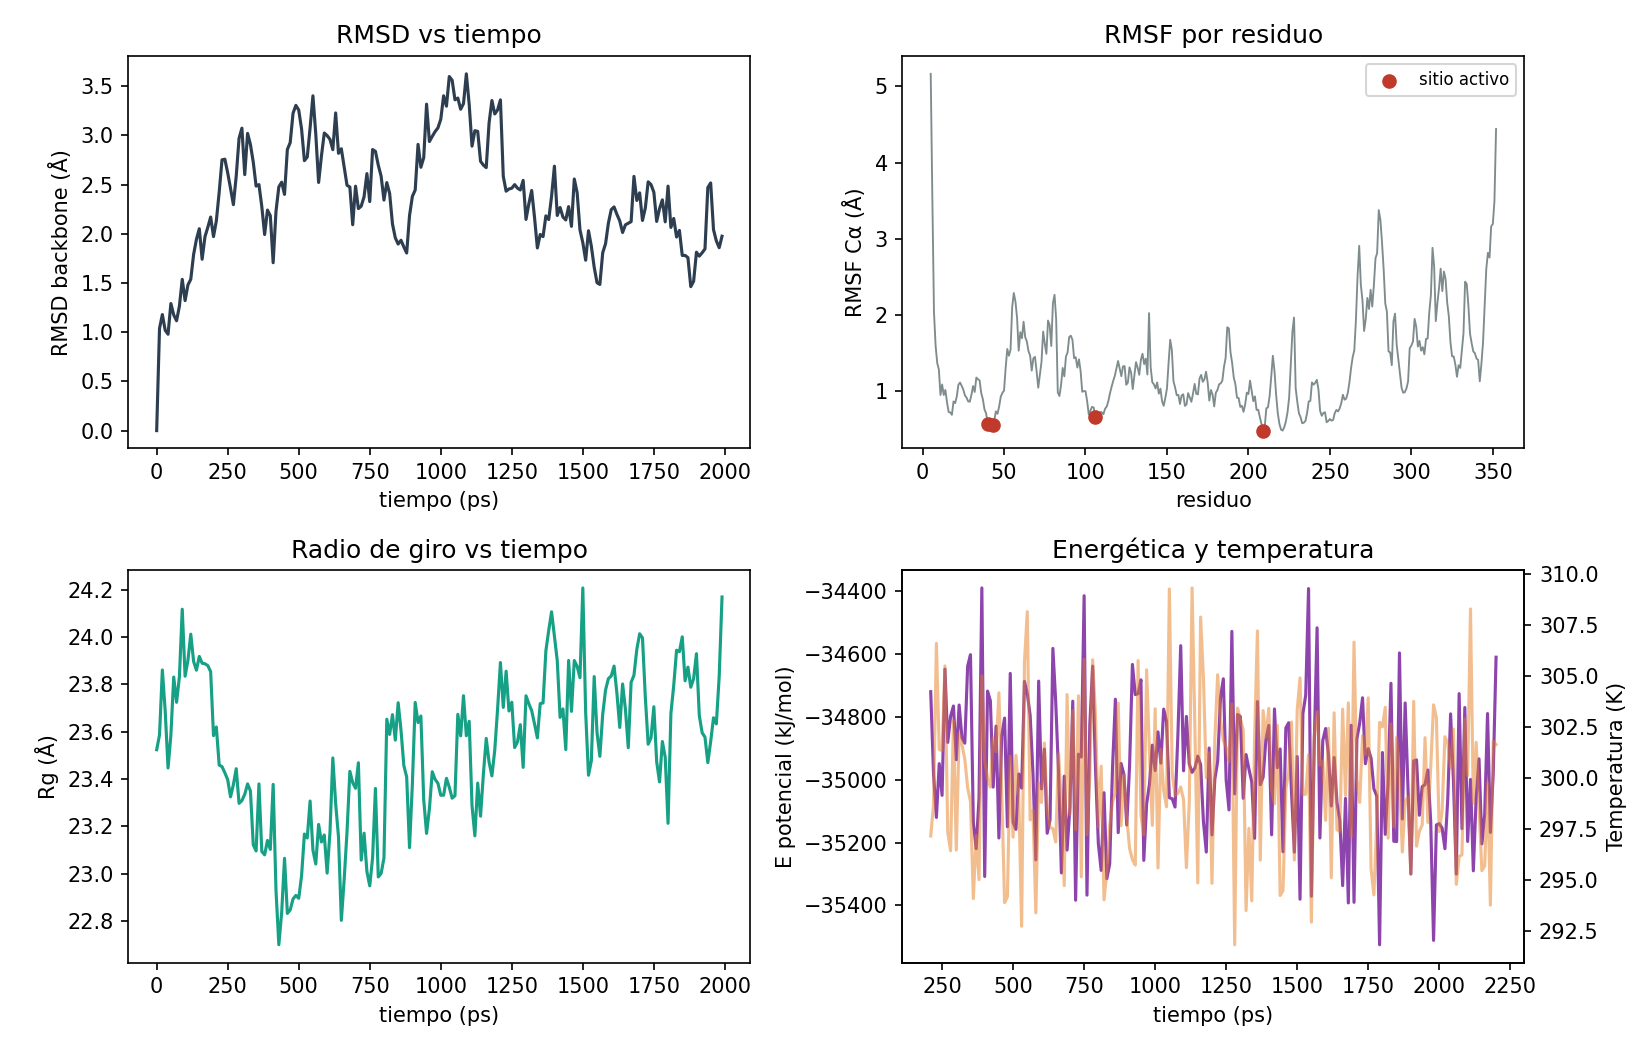

RMSD plateau (ultimo 10%): 1.95 A
Rg medio: 23.52 A (sd 0.315)
Temperatura media: 299.9 K
Top-5 residuos flexibles: ['THR5=5.2A', 'GLY352=4.4A', 'VAL6=3.5A', 'GLY351=3.5A', 'ASP280=3.4A']
RMSF sitio activo: ['SER40=0.57A', 'LYS43=0.55A', 'SER106=0.67A', 'LYS209=0.49A']


In [18]:
md_res = md.analyze_md(
    md_out["topology"], md_out["trajectory"], md_dir,
    frame_dt_ps=MD_REPORT_PS, active_site=(40, 43, 106, 209),
)
rmsd_df, rmsf_df, rg_df = md_res["rmsd"], md_res["rmsf"], md_res["rg"]

# energética desde el log de StateData (normaliza nombres de columna)
mdlog = pd.read_csv(md_out["log"])
mdlog.columns = [c.strip().lstrip("#").strip().replace('"', "") for c in mdlog.columns]
time_col = next(c for c in mdlog.columns if c.startswith("Time"))
pe_col = next(c for c in mdlog.columns if "Potential" in c)
temp_col = next(c for c in mdlog.columns if "Temperature" in c)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].plot(rmsd_df["time_ps"], rmsd_df["rmsd_A"], color="#2c3e50")
axes[0, 0].set(xlabel="tiempo (ps)", ylabel="RMSD backbone (Å)", title="RMSD vs tiempo")

axes[0, 1].plot(rmsf_df["resid"], rmsf_df["rmsf_A"], color="#7f8c8d", lw=0.9)
hot = rmsf_df[rmsf_df["is_active_site"]]
axes[0, 1].scatter(hot["resid"], hot["rmsf_A"], color="#c0392b", zorder=5, label="sitio activo")
axes[0, 1].set(xlabel="residuo", ylabel="RMSF Cα (Å)", title="RMSF por residuo")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(rg_df["time_ps"], rg_df["rg_A"], color="#16a085")
axes[1, 0].set(xlabel="tiempo (ps)", ylabel="Rg (Å)", title="Radio de giro vs tiempo")

ax2 = axes[1, 1]
ax2.plot(mdlog[time_col], mdlog[pe_col], color="#8e44ad")
ax2.set(xlabel="tiempo (ps)", ylabel="E potencial (kJ/mol)", title="Energética y temperatura")
ax3 = ax2.twinx()
ax3.plot(mdlog[time_col], mdlog[temp_col], color="#e67e22", alpha=0.5)
ax3.set_ylabel("Temperatura (K)")

fig.tight_layout()
md_png = OUT / "md_summary.png"
fig.savefig(md_png, dpi=150)
plt.close(fig)
print("Figura MD:", md_png)
display(Image(str(md_png)))

tail = max(1, len(rmsd_df) // 10)
print(f"RMSD plateau (ultimo 10%): {rmsd_df['rmsd_A'].tail(tail).mean():.2f} A")
print(f"Rg medio: {rg_df['rg_A'].mean():.2f} A (sd {rg_df['rg_A'].std():.3f})")
print(f"Temperatura media: {mdlog[temp_col].mean():.1f} K")
top_flex = rmsf_df.sort_values("rmsf_A", ascending=False).head(5)
print("Top-5 residuos flexibles:",
      [f"{r.resname}{r.resid}={r.rmsf_A:.1f}A" for r in top_flex.itertuples()])
print("RMSF sitio activo:",
      [f"{r.resname}{r.resid}={r.rmsf_A:.2f}A" for r in hot.itertuples()])

### Resultados de energética y dinámica global

Trayectoria de **2 ns** (200 frames cada 10 ps) del receptor apo, ff14SB + OBC2, en **GPU (OpenCL, ~27 min)**.

| Métrica | Valor | Lectura |
|---------|-------|---------|
| **Temperatura media** | **299.9 K** | Termostato en diana (300 K) ✓ |
| **Energía potencial** | **−34 970 ± 214 kJ/mol** | Estable, sin deriva → sistema bien equilibrado |
| **RMSD backbone** | sube a ~3.6 Å y se asienta en **≈1.95 Å** (media 2.37 Å) | Relajación inicial y **plateau** → plegamiento estable, sin cambios conformacionales grandes |
| **Rg (radio de giro)** | **23.52 ± 0.32 Å** (22.7–24.2) | Prácticamente constante → estructura **compacta**, sin desplegamiento ni colapso |
| **RMSF media** | 1.34 Å (máx 5.16) | Flexibilidad típica de proteína globular |

**Flexibilidad (RMSF).** Los picos están, como se espera, en los **extremos N/C** (Thr5 ≈ 5.2 Å, Gly352 ≈ 4.4 Å, Val6, Gly351) y un **lazo expuesto** (Asp280 ≈ 3.4 Å).

**Sitio activo rígido — el resultado biológicamente relevante.** Los cuatro residuos catalíticos tienen RMSF muy por debajo de la media global (1.34 Å):

| Residuo | RMSF (Å) |
|---------|----------|
| Ser40 (nucleófilo) | **0.57** |
| Lys43 (base general) | **0.55** |
| Ser106 (SXN) | **0.67** |
| Lys209 (KTG) | **0.49** |

La maquinaria catalítica (motivos SXXK/SXN/KTG) se mantiene **preorganizada y poco móvil** durante toda la simulación (media del sitio activo 0.57 Å). Esto es coherente con la baja RMSD global y **respalda la hipótesis de receptor rígido** del docking (secciones 1–7): el bolsillo no se reorganiza apreciablemente, así que la pose dockeada sobre la estructura cristalográfica sigue siendo geométricamente válida en el conjunto dinámico.

> **Recordatorio de alcance:** MD **apo** (sin ligando), **solvente implícito**, **2 ns**. Es evidencia de *estabilidad estructural del sitio activo*, no una medida de la permanencia del ligando ni de la energética de unión (eso exigiría parametrizar la cefoxitina y simular el complejo solvatado en escalas de ns–μs con réplicas).

## 10. Validación por MTT (nota)

El **ensayo MTT** (reducción de la sal de tetrazolio MTT a formazán por células metabólicamente activas, leído por absorbancia a ~570 nm) es un **experimento de laboratorio húmedo** de viabilidad/citotoxicidad celular. **No puede generarse in silico** y **no existe dato experimental de este tipo en el proyecto**, que es puramente computacional (docking + MD).

Para obtener una validación por MTT habría que, en el banco:
1. Cultivar la línea celular o cepa bacteriana relevante (p. ej. *E. coli* para actividad antibacteriana, o una línea celular para citotoxicidad).
2. Exponer a una **serie de diluciones** de cefoxitina.
3. Incubar con MTT, solubilizar el formazán y medir **absorbancia**.
4. Ajustar una curva dosis–respuesta y reportar **IC₅₀/MIC** con réplicas y controles.

Estos números deben provenir del experimento; cualquier valor "calculado" sería inventado. Lo que el pipeline computacional sí aporta como evidencia complementaria es: afinidad de docking, huella de contactos con el sitio activo, distancia pre-acilación Ser40 (sección 5) y la estabilidad estructural por MD (sección 9).